## Intsall Library

In [1]:
!pip install -U pip setuptools wheel

In [2]:
!pip install -U datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 9.1 MB/s  0:00:00
  Attempting uninstall: datasets
    Found existing installation: datasets 4.8.5
    Uninstalling datasets-4.8.5:
      Successfully uninstalled datasets-4.8.5


In [3]:
!pip install -U scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 33.2 MB/s  0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [4]:
!pip install -U seqeval

  Using cached seqeval-1.2.2.tar.gz (43 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16251 sha256=f577247bdc3c943df7c3eb2f8df6dd5c3f0b9a4d801acb8fe72a3caeb0a66105
  Stored in directory: /root/.cache/pip/wheels/14/cf/a7/8f28ef376d707ff10e3922899482a2f23ef3002f8a952f47ac
Successfully built seqeval


In [6]:
!pip install -U datasets scikit-learn

In [9]:
from datasets import load_dataset

ds = load_dataset("tomaarsen/conll2003")

print(ds)

DatasetDict({
    train: Dataset({
        features: ['id', 'document_id', 'sentence_id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'document_id', 'sentence_id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'document_id', 'sentence_id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})


In [11]:
print(ds["train"][0])

{'id': '0', 'document_id': 1, 'sentence_id': 0, 'tokens': ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.'], 'pos_tags': [22, 42, 16, 21, 35, 37, 16, 21, 7], 'chunk_tags': [11, 21, 11, 12, 21, 22, 11, 12, 0], 'ner_tags': [3, 0, 7, 0, 0, 0, 7, 0, 0]}


In [12]:
print(ds["train"].features["ner_tags"].feature.names)

['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']


In [13]:
label_names = ds["train"].features["ner_tags"].feature.names

for i, label in enumerate(label_names):
    print(i, "→", label)

0 → O
1 → B-PER
2 → I-PER
3 → B-ORG
4 → I-ORG
5 → B-LOC
6 → I-LOC
7 → B-MISC
8 → I-MISC


In [14]:
tokens = ds["train"][0]["tokens"]
ner_tags = ds["train"][0]["ner_tags"]

for token, tag_id in zip(tokens, ner_tags):
    print(f"{token:15} → {label_names[tag_id]}")

EU              → B-ORG
rejects         → O
German          → B-MISC
call            → O
to              → O
boycott         → O
British         → B-MISC
lamb            → O
.               → O


In [15]:
tokens = ds["train"][0]["tokens"]
ner_tags = ds["train"][0]["ner_tags"]

for token, tag_id in zip(tokens, ner_tags):
    print(f"{token:15} → {label_names[tag_id]}")

EU              → B-ORG
rejects         → O
German          → B-MISC
call            → O
to              → O
boycott         → O
British         → B-MISC
lamb            → O
.               → O


In [16]:
label2id = {
    "O": 0,
    "B-PER": 1,
    "I-PER": 2,
    "B-ORG": 3,
    "I-ORG": 4,
    "B-LOC": 5,
    "I-LOC": 6
}

id2label = {
    value: key
    for key, value in label2id.items()
}

print(label2id)
print(id2label)

{'O': 0, 'B-PER': 1, 'I-PER': 2, 'B-ORG': 3, 'I-ORG': 4, 'B-LOC': 5, 'I-LOC': 6}
{0: 'O', 1: 'B-PER', 2: 'I-PER', 3: 'B-ORG', 4: 'I-ORG', 5: 'B-LOC', 6: 'I-LOC'}


In [17]:
def convert_ner_labels(example):
    converted_labels = []

    for tag_id in example["ner_tags"]:
        original_label = label_names[tag_id]

        if original_label in label2id:
            converted_labels.append(
                label2id[original_label]
            )
        else:
            # B-MISC / I-MISC → O
            converted_labels.append(
                label2id["O"]
            )

    example["labels"] = converted_labels

    return example

In [18]:
ds = ds.map(convert_ner_labels)

print(ds["train"][0])

Map:   0%|          | 0/14041 [00:00<?, ? examples/s]

Map:   0%|          | 0/3250 [00:00<?, ? examples/s]

Map:   0%|          | 0/3453 [00:00<?, ? examples/s]

{'id': '0', 'document_id': 1, 'sentence_id': 0, 'tokens': ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.'], 'pos_tags': [22, 42, 16, 21, 35, 37, 16, 21, 7], 'chunk_tags': [11, 21, 11, 12, 21, 22, 11, 12, 0], 'ner_tags': [3, 0, 7, 0, 0, 0, 7, 0, 0], 'labels': [3, 0, 0, 0, 0, 0, 0, 0, 0]}


In [19]:
from collections import Counter

word_counter = Counter()

for sentence in ds["train"]["tokens"]:
    for word in sentence:
        word_counter[word] += 1

print("Total unique words:", len(word_counter))

Total unique words: 23623


## STEP 6.1 — Vocabulary dictionary

In [20]:
word2id = {
    "<PAD>": 0,
    "<UNK>": 1
}

for word in word_counter.keys():
    if word not in word2id:
        word2id[word] = len(word2id)

print("Vocabulary size:", len(word2id))

Vocabulary size: 23625


In [21]:
id2word = {
    idx: word
    for word, idx in word2id.items()
}

print(id2word[0])
print(id2word[1])

<PAD>
<UNK>


## STEP 7 — Words → Numbers

In [22]:
def encode_sentence(tokens):
    return [
        word2id.get(word, word2id["<UNK>"])
        for word in tokens
    ]

In [23]:
sample_tokens = ds["train"][0]["tokens"]

print("Original:")
print(sample_tokens)

print("\nEncoded:")
print(encode_sentence(sample_tokens))

Original:
['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']

Encoded:
[2, 3, 4, 5, 6, 7, 8, 9, 10]


## STEP 7.1 — Entire dataset encode karein

In [24]:
def encode_dataset(dataset_split):
    return [
        encode_sentence(tokens)
        for tokens in dataset_split["tokens"]
    ]


X_train = encode_dataset(ds["train"])
X_val = encode_dataset(ds["validation"])
X_test = encode_dataset(ds["test"])

In [25]:
print("First training sentence:")
print(X_train[0])

print("\nCorresponding labels:")
print(ds["train"][0]["labels"])

First training sentence:
[2, 3, 4, 5, 6, 7, 8, 9, 10]

Corresponding labels:
[3, 0, 0, 0, 0, 0, 0, 0, 0]


## STEP 8 — Padding

In [27]:
import numpy as np

In [28]:
MAX_LEN = 128

def pad_sequences_custom(sequences, max_len, pad_value=0):

    padded_sequences = []

    for sequence in sequences:

        if len(sequence) > max_len:
            sequence = sequence[:max_len]

        else:
            sequence = sequence + [
                pad_value
            ] * (max_len - len(sequence))

        padded_sequences.append(sequence)

    return np.array(padded_sequences)

## STEP 8.1 — X data padding

In [29]:
X_train = pad_sequences_custom(
    X_train,
    MAX_LEN,
    pad_value=word2id["<PAD>"]
)

X_val = pad_sequences_custom(
    X_val,
    MAX_LEN,
    pad_value=word2id["<PAD>"]
)

X_test = pad_sequences_custom(
    X_test,
    MAX_LEN,
    pad_value=word2id["<PAD>"]
)

In [30]:
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_train shape: (14041, 128)
X_val shape: (3250, 128)
X_test shape: (3453, 128)


## STEP 8.2 — Labels bhi pad karne hain

In [31]:
def pad_label_sequences(
    label_sequences,
    max_len,
    pad_value=0
):

    padded_sequences = []

    for labels in label_sequences:

        if len(labels) > max_len:
            labels = labels[:max_len]

        else:
            labels = labels + [
                pad_value
            ] * (max_len - len(labels))

        padded_sequences.append(labels)

    return np.array(padded_sequences)

In [32]:
y_train = pad_label_sequences(
    ds["train"]["labels"],
    MAX_LEN
)

y_val = pad_label_sequences(
    ds["validation"]["labels"],
    MAX_LEN
)

y_test = pad_label_sequences(
    ds["test"]["labels"],
    MAX_LEN
)

In [33]:
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

y_train shape: (14041, 128)
y_val shape: (3250, 128)
y_test shape: (3453, 128)


## STEP 8.3 — Very important: Input vs Labels

In [34]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    GRU,
    Dropout,
    Dense
)

In [35]:
NUM_CLASSES = len(label2id)
VOCAB_SIZE = len(word2id)

model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        mask_zero=True
    ),

    Bidirectional(
        GRU(
            128,
            return_sequences=True
        )
    ),

    Dropout(0.3),

    Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

In [36]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## STEP 10 — Compile

In [37]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [38]:
print(len(word2id))
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

23625
(14041, 128)
(3250, 128)
(3453, 128)
(14041, 128)
(3250, 128)
(3453, 128)


## Step 9 — GRU Model ko properly build karein

In [39]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Bidirectional,
    GRU,
    Dropout,
    Dense
)

NUM_CLASSES = len(label2id)
VOCAB_SIZE = len(word2id)

model = Sequential([

    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        mask_zero=True
    ),

    Bidirectional(
        GRU(
            128,
            return_sequences=True
        )
    ),

    Dropout(0.3),

    Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

In [40]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 128, 128)       │     3,024,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128, 256)       │       198,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128, 7)         │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,223,943 (12.30 MB)

 Trainable params: 3,223,943 (12.30 MB)

 Non-trainable params: 0 (0.00 B)

## Step 10 — Model Compile

In [41]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Step 10.1 — Padding mask create karein

In [42]:
train_sample_weights = (X_train != word2id["<PAD>"]).astype("float32")

val_sample_weights = (X_val != word2id["<PAD>"]).astype("float32")

test_sample_weights = (X_test != word2id["<PAD>"]).astype("float32")

In [43]:
print(train_sample_weights[0])

[1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0.]


## Step 11 — Train the GRU Model

In [44]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [45]:
history = model.fit(
    X_train,
    y_train,
    sample_weight=train_sample_weights,

    validation_data=(
        X_val,
        y_val,
        val_sample_weights
    ),

    epochs=10,
    batch_size=64,

    callbacks=[early_stopping]
)

Epoch 1/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8886 - loss: 0.4368 - val_accuracy: 0.9404 - val_loss: 0.2111
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9752 - loss: 0.0885 - val_accuracy: 0.9619 - val_loss: 0.1285
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9927 - loss: 0.0299 - val_accuracy: 0.9638 - val_loss: 0.1301
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9960 - loss: 0.0154 - val_accuracy: 0.9647 - val_loss: 0.1239
Epoch 5/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9977 - loss: 0.0091 - val_accuracy: 0.9648 - val_loss: 0.1392
Epoch 6/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9985 - loss: 0.0060 - val_accuracy: 0.9648 - val_loss: 0.1408


## Test Model

In [46]:
test_results = model.evaluate(
    X_test,
    y_test,
    sample_weight=test_sample_weights,
    verbose=1
)

print("Test Loss:", test_results[0])
print("Test Accuracy:", test_results[1])

108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9441 - loss: 0.2273
Test Loss: 0.22734332084655762
Test Accuracy: 0.9440938830375671


In [47]:
predictions = model.predict(
    X_test,
    batch_size=64,
    verbose=1
)

predicted_ids = np.argmax(predictions, axis=-1)

print("Prediction shape:", predicted_ids.shape)

54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
Prediction shape: (3453, 128)


In [48]:
!pip install seqeval -q

In [49]:
from seqeval.metrics import (
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

true_sequences = []
pred_sequences = []

for i in range(len(y_test)):

    true_labels = []
    pred_labels = []

    # Use the original sentence length
    original_length = min(
        len(ds["test"][i]["labels"]),
        MAX_LEN
    )

    for j in range(original_length):

        true_label = id2label[y_test[i][j]]
        pred_label = id2label[predicted_ids[i][j]]

        true_labels.append(true_label)
        pred_labels.append(pred_label)

    true_sequences.append(true_labels)
    pred_sequences.append(pred_labels)


print("Precision:", precision_score(true_sequences, pred_sequences))
print("Recall:", recall_score(true_sequences, pred_sequences))
print("F1 Score:", f1_score(true_sequences, pred_sequences))

print("\nClassification Report:\n")
print(classification_report(true_sequences, pred_sequences))

Precision: 0.7264719517848864
Recall: 0.6336433481601293
F1 Score: 0.6768898488120949

Classification Report:

              precision    recall  f1-score   support

         LOC       0.80      0.74      0.77      1668
         ORG       0.67      0.61      0.64      1661
         PER       0.70      0.55      0.62      1617

   micro avg       0.73      0.63      0.68      4946
   macro avg       0.72      0.63      0.67      4946
weighted avg       0.73      0.63      0.68      4946



## Step 11.1 — Training Graph

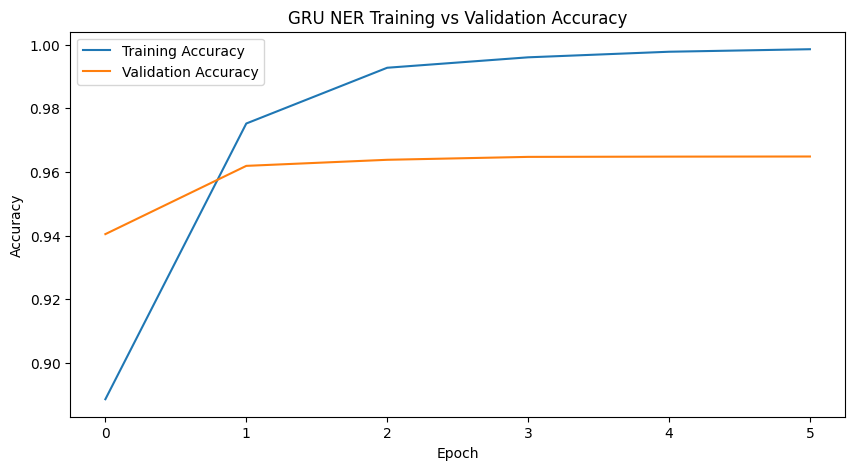

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GRU NER Training vs Validation Accuracy")

plt.legend()
plt.show()

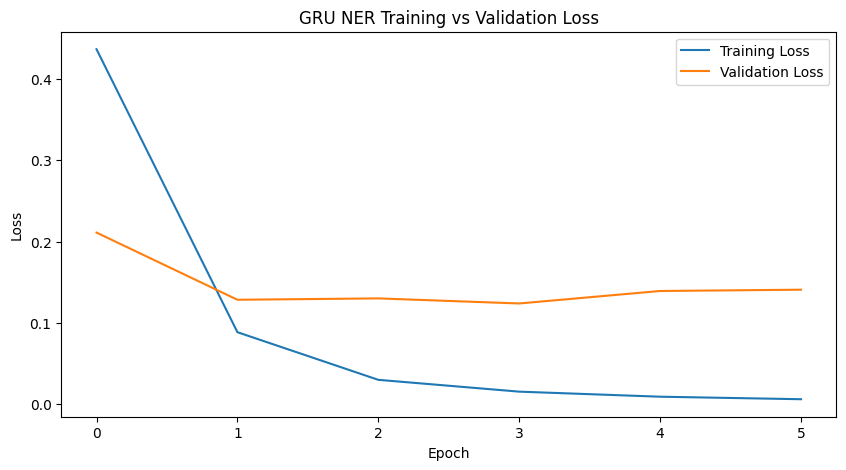

In [51]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GRU NER Training vs Validation Loss")

plt.legend()
plt.show()

In [52]:
test_results = model.evaluate(
    X_test,
    y_test,
    sample_weight=test_sample_weights,
    verbose=1
)

print("Test Loss:", test_results[0])
print("Test Accuracy:", test_results[1])

108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9441 - loss: 0.2273
Test Loss: 0.22734332084655762
Test Accuracy: 0.9440938830375671


In [53]:
predictions = model.predict(
    X_test,
    batch_size=64
)

predicted_ids = np.argmax(
    predictions,
    axis=-1
)

print("Prediction shape:", predicted_ids.shape)

54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Prediction shape: (3453, 128)


## Step 14 — Create Custom Text Prediction

In [54]:
import re
import numpy as np

def tokenize_text(text):
    """
    Split words and punctuation separately.
    Example:
    'Elon Musk visited London.'
    ->
    ['Elon', 'Musk', 'visited', 'London', '.']
    """
    return re.findall(r"\w+|[^\w\s]", text)


def predict_entities(text):

    # Tokenize input
    words = tokenize_text(text)

    # Convert words to IDs
    sequence = [
        word2id.get(word, word2id["<UNK>"])
        for word in words
    ]

    # Keep maximum length
    original_length = min(len(sequence), MAX_LEN)

    sequence = sequence[:MAX_LEN]

    # Padding
    padded_sequence = sequence + [
        word2id["<PAD>"]
    ] * (MAX_LEN - len(sequence))

    # Convert to NumPy
    padded_sequence = np.array([padded_sequence])

    # Model prediction
    prediction = model.predict(
        padded_sequence,
        verbose=0
    )

    # Get predicted class
    predicted_ids = np.argmax(
        prediction,
        axis=-1
    )[0]

    # Store results
    results = []

    for i, word in enumerate(words[:MAX_LEN]):

        label = id2label[predicted_ids[i]]

        results.append({
            "word": word,
            "label": label
        })

    return results

In [55]:
text = """
Elon Musk visited London and met officials
from Tesla at the University of Oxford.
"""

results = predict_entities(text)

for item in results:
    print(item["word"], "->", item["label"])

Elon -> O
Musk -> O
visited -> O
London -> B-LOC
and -> O
met -> O
officials -> O
from -> O
Tesla -> O
at -> O
the -> O
University -> B-ORG
of -> I-ORG
Oxford -> I-ORG
. -> O


## Step 16 — Convert BIO Predictions into Entities

In [56]:
def extract_entities(results):

    entities = []

    current_entity = []
    current_type = None

    for item in results:

        word = item["word"]
        label = item["label"]

        # Beginning of an entity
        if label.startswith("B-"):

            # Save previous entity
            if current_entity:
                entities.append({
                    "text": " ".join(current_entity),
                    "type": current_type
                })

            current_entity = [word]
            current_type = label[2:]

        # Continuation of an entity
        elif label.startswith("I-"):

            entity_type = label[2:]

            if current_entity and entity_type == current_type:
                current_entity.append(word)

            else:
                # Handle incorrect I- prediction
                if current_entity:
                    entities.append({
                        "text": " ".join(current_entity),
                        "type": current_type
                    })

                current_entity = [word]
                current_type = entity_type

        # Outside any entity
        else:

            if current_entity:
                entities.append({
                    "text": " ".join(current_entity),
                    "type": current_type
                })

                current_entity = []
                current_type = None

    # Save final entity
    if current_entity:
        entities.append({
            "text": " ".join(current_entity),
            "type": current_type
        })

    return entities

In [57]:
entities = extract_entities(results)

print("Detected Entities:\n")

for entity in entities:
    print(
        entity["text"],
        "->",
        entity["type"]
    )

Detected Entities:

London -> LOC
University of Oxford -> ORG


In [58]:
text = """
Bill Gates founded Microsoft in the United States and
later visited Paris for a technology conference.
"""

results = predict_entities(text)

for item in results:
    print(item["word"], "->", item["label"])

print("\nDetected Entities:\n")

entities = extract_entities(results)

for entity in entities:
    print(entity["text"], "->", entity["type"])

Bill -> B-PER
Gates -> I-PER
founded -> O
Microsoft -> B-ORG
in -> O
the -> O
United -> B-LOC
States -> I-LOC
and -> O
later -> O
visited -> O
Paris -> B-LOC
for -> O
a -> O
technology -> O
conference -> O
. -> O

Detected Entities:

Bill Gates -> PER
Microsoft -> ORG
United States -> LOC
Paris -> LOC


In [59]:
text = """
Barack Obama met Angela Merkel in Berlin.
They discussed cooperation between the United Nations
and the European Union.
"""

results = predict_entities(text)

for item in results:
    print(item["word"], "->", item["label"])

print("\nDetected Entities:\n")

entities = extract_entities(results)

for entity in entities:
    print(entity["text"], "->", entity["type"])

Barack -> O
Obama -> O
met -> O
Angela -> O
Merkel -> O
in -> O
Berlin -> B-LOC
. -> O
They -> O
discussed -> O
cooperation -> O
between -> O
the -> O
United -> B-ORG
Nations -> I-ORG
and -> O
the -> O
European -> B-ORG
Union -> I-ORG
. -> O

Detected Entities:

Berlin -> LOC
United Nations -> ORG
European Union -> ORG


In [60]:
model.save("gru_ner_model.keras")

import pickle

with open("word2id.pkl", "wb") as f:
    pickle.dump(word2id, f)

with open("id2label.pkl", "wb") as f:
    pickle.dump(id2label, f)

print("Model and files saved successfully!")

Model and files saved successfully!
